# Blood Pressure Estimation with Neural Networks ~ Resource Profiling Notebook

In this notebook it is possible to find a tutorial on how to personalize a pretrained neural-network (NN) on a specific subject.
Specifically, the NN has been trained to __quickly__ learn how to predict blood pressure values (SBP/DBP/MAP) from the photoplethysmography (PPG) signal associated with a subject. Predicting the full BP waveform is a more diffcult task than predicting the BP values. This enables the adoption of smaller models when predicting SBP/DBP/MAP. This is important for the sake of resource efficiency and prolong the battery duration when the model run on a real device. The netobook shows how to load the pretrained NN and alternate personalization to the BP values predictions on a stream of PPG windows of a subject from the [Vital DB](https://www.nature.com/articles/s41597-022-01411-5) dataset. As the NN undergoes personalization/prediction, it is possible to profile its resource consumptions during training and testing for deployment on a real device. Given the battery of a real device and the resource consumption of the algorithm it is possible to estimate its lifetime. 

![Model Inference Visualization](deployment_overview_no_sig2sig.png)

## Setup Environment

In [20]:
import os
import sys
project_root = os.path.abspath("..")
folders_to_add = ['data', 'models', 'training_utils']
for folder in folders_to_add:
    sys.path.append(project_root) #if the cell does not run, try to replace this line with 'sys.path.append(os.path.join(project_root, folder))'
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torchinfo import summary
from thop import profile
from models.MAMLLearner import MAMLLearner
from training_utils.helpers import get_encoder_architecture, get_prediction_head_architecture, build_inner_optimizer

# Minimal config for demo
subject_id = 'p001326'
config = {
    "seed": 42,
    "runs_path": f"./data/{subject_id}_runs.pkl",
    "samples_path": f"./data/{subject_id}_samples.npz",
    "model_name": 'ResGruNet',
    "fs": 125,
    "input_seq_len_s": 10,
    "ecg": False, # Set the model to PPG Only!
    "sig2sig": False, # Set the model to predict SBP/DBP/MAP
    "channels": '1, 64, 128, 256',
    "kernel_size": 7,
    "act": 'leaky_relu',
    "pooling": 'avg',
    "embed_dim": 256,
    "num_groups": 8,
    "inner_adapt": 'head',
    "inner_opt": 'adam',
    "inner_head_lr_mult": 1.0,
    "inner_backbone_lr_mult": 0.1,
    "min_run_length": 128,
    "personalization_batch_size": 16,
    "personalization_lr": 1e-2,
    "personalization_steps": 8,
    "criterion": "SmoothL1Loss",
    "grad_clip": 10.0,
    "pretrained_model_ckpt_path": "./models/resgrunet_ppg_no_sig2sig",
}

# Print the loaded configuration
print(config)

# Decide the device to use to run the model
if torch.cuda.is_available():
    # Select the gpu to be usesd
    os.environ['CUDA_VISIBLE_DEVICES'] = "0"
    device = torch._C.device("cuda:0")
    print("Using GPU 0.")
else:
    device = torch.device("cpu")
    print("GPU not available. Using CPU.")

if config['ecg'] or config['sig2sig']:
    raise ValueError("This notebook is intended to be used only with PPG to BP waveform ...")

{'seed': 42, 'runs_path': './data/p001326_runs.pkl', 'samples_path': './data/p001326_samples.npz', 'model_name': 'ResGruNet', 'fs': 125, 'input_seq_len_s': 10, 'ecg': False, 'sig2sig': False, 'channels': '1, 64, 128, 256', 'kernel_size': 7, 'act': 'leaky_relu', 'pooling': 'avg', 'embed_dim': 256, 'num_groups': 8, 'inner_adapt': 'head', 'inner_opt': 'adam', 'inner_head_lr_mult': 1.0, 'inner_backbone_lr_mult': 0.1, 'min_run_length': 128, 'personalization_batch_size': 16, 'personalization_lr': 0.01, 'personalization_steps': 8, 'criterion': 'SmoothL1Loss', 'grad_clip': 10.0, 'pretrained_model_ckpt_path': './models/resgrunet_ppg_no_sig2sig'}
Using GPU 0.


## Data Loading

In [2]:
def plot_subject_annotation_runs_from_files(
    data,
    runs,
    subject_id="p001326"
):
    """
    Plot annotation statistics for a subject using pre-extracted data and run definitions.

    Parameters
    ----------
    data : np.lib.npyio.NpzFile
        Loaded data for a single subject (as from np.load(samples_path, allow_pickle=True)).
        Must contain 'idxs', 'sbps', 'dbps', 'maps'.
    runs : list of dict
        Each dict contains 'train' and 'test' sample IDs, 'r_idx', and 'b_idx'.
    subject_id : str
        Subject identifier.
    savepath : str
        File path to save the figure.
    show_bp_plot : bool, optional
        If True, show the figure instead of saving. Default=False.
    """

    # === Helper function to extract annotations ===
    def get_annotations(sample_ids):
        sbp_values, dbp_values, map_values = [], [], []
        for sid in sample_ids:
            # Find index of this sample in data['idxs']
            idx_arr = np.where(data['idxs'] == sid)[0]
            idx = int(idx_arr[0])
            sbp_values.append(float(data['sbps'][idx]))
            dbp_values.append(float(data['dbps'][idx]))
            map_values.append(float(data['maps'][idx]))
        return sbp_values, dbp_values, map_values

    # === Collect all data into lists for DataFrame ===
    run_idxs_list, block_list, set_list = [], [], []
    sbp_list, dbp_list, map_list, window_indices = [], [], [], []

    for block in runs:
        # Training
        train_sbp, train_dbp, train_map = get_annotations(block["train"])
        train_indices = [
            int(np.where(data['idxs'] == sid)[0][0])
            for sid in block["train"]
            if sid in data['idxs']
        ]

        run_idxs_list.extend([block["r_idx"]] * len(train_sbp))
        block_list.extend([block["b_idx"]] * len(train_sbp))
        set_list.extend(["training"] * len(train_sbp))
        sbp_list.extend(train_sbp)
        dbp_list.extend(train_dbp)
        map_list.extend(train_map)
        window_indices.extend(train_indices)

        # Testing
        test_sbp, test_dbp, test_map = get_annotations(block["test"])
        test_indices = [
            int(np.where(data['idxs'] == sid)[0][0])
            for sid in block["test"]
            if sid in data['idxs']
        ]

        run_idxs_list.extend([block["r_idx"]] * len(test_sbp))
        block_list.extend([block["b_idx"]] * len(test_sbp))
        set_list.extend(["testing"] * len(test_sbp))
        sbp_list.extend(test_sbp)
        dbp_list.extend(test_dbp)
        map_list.extend(test_map)
        window_indices.extend(test_indices)

    # === Build DataFrame ===
    df = pd.DataFrame({
        "window_index": window_indices,
        "run_idx": run_idxs_list,
        "block": block_list,
        "set": set_list,
        "sbp": sbp_list,
        "dbp": dbp_list,
        "map": map_list,
    }).sort_values(by="window_index").reset_index(drop=True)

    # === Create the plots ===
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Subject {subject_id} - Annotation Statistics", fontsize=14, fontweight="bold")

    # Subplot 1 — Window index vs Block number (by Run)
    ax1 = axes[0]
    unique_runs = df["run_idx"].unique()
    colors_runs = plt.cm.tab10(np.linspace(0, 1, len(unique_runs)))
    for i, run_idx in enumerate(unique_runs):
        run_data = df[df["run_idx"] == run_idx]
        ax1.scatter(
            run_data["window_index"], run_data["block"],
            c=[colors_runs[i]], label=f"Run {run_idx}", alpha=0.7, s=30
        )
    ax1.set_ylabel("Block Number")
    ax1.set_title("Window Index vs Block Number")
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # Subplot 2 — Training vs Testing
    ax2 = axes[1]
    adaptation_data = df[df["set"] == "training"]
    validation_data = df[df["set"] == "testing"]
    ax2.scatter(adaptation_data["window_index"], np.ones(len(adaptation_data)), c="red", label="Training", alpha=0.7, s=30)
    ax2.scatter(validation_data["window_index"], np.ones(len(validation_data))*2, c="blue", label="Testing", alpha=0.7, s=30)
    ax2.set_yticks([1, 2])
    ax2.set_yticklabels(["Training", "Testing"])
    ax2.set_ylabel("Set Type")
    ax2.set_title("Window Index vs Set Type")
    ax2.grid(True, alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # Subplot 3 — SBP/DBP/MAP
    ax3 = axes[2]
    ax3.plot(df["window_index"], df["sbp"], "o-", color="red", label="SBP", alpha=0.7, markersize=4, linewidth=1)
    ax3.plot(df["window_index"], df["dbp"], "o-", color="blue", label="DBP", alpha=0.7, markersize=4, linewidth=1)
    ax3.plot(df["window_index"], df["map"], "o-", color="green", label="MAP", alpha=0.7, markersize=4, linewidth=1)
    ax3.set_ylabel("Blood Pressure (mmHg)")
    ax3.set_xlabel("Window Index")
    ax3.set_title("Window Index vs Blood Pressure Values")
    ax3.grid(True, alpha=0.3)
    ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    plt.show()


Subject p001326 has 14 blocks of contiguous valid samples, each with 16 samples for training and 16 samples for validation


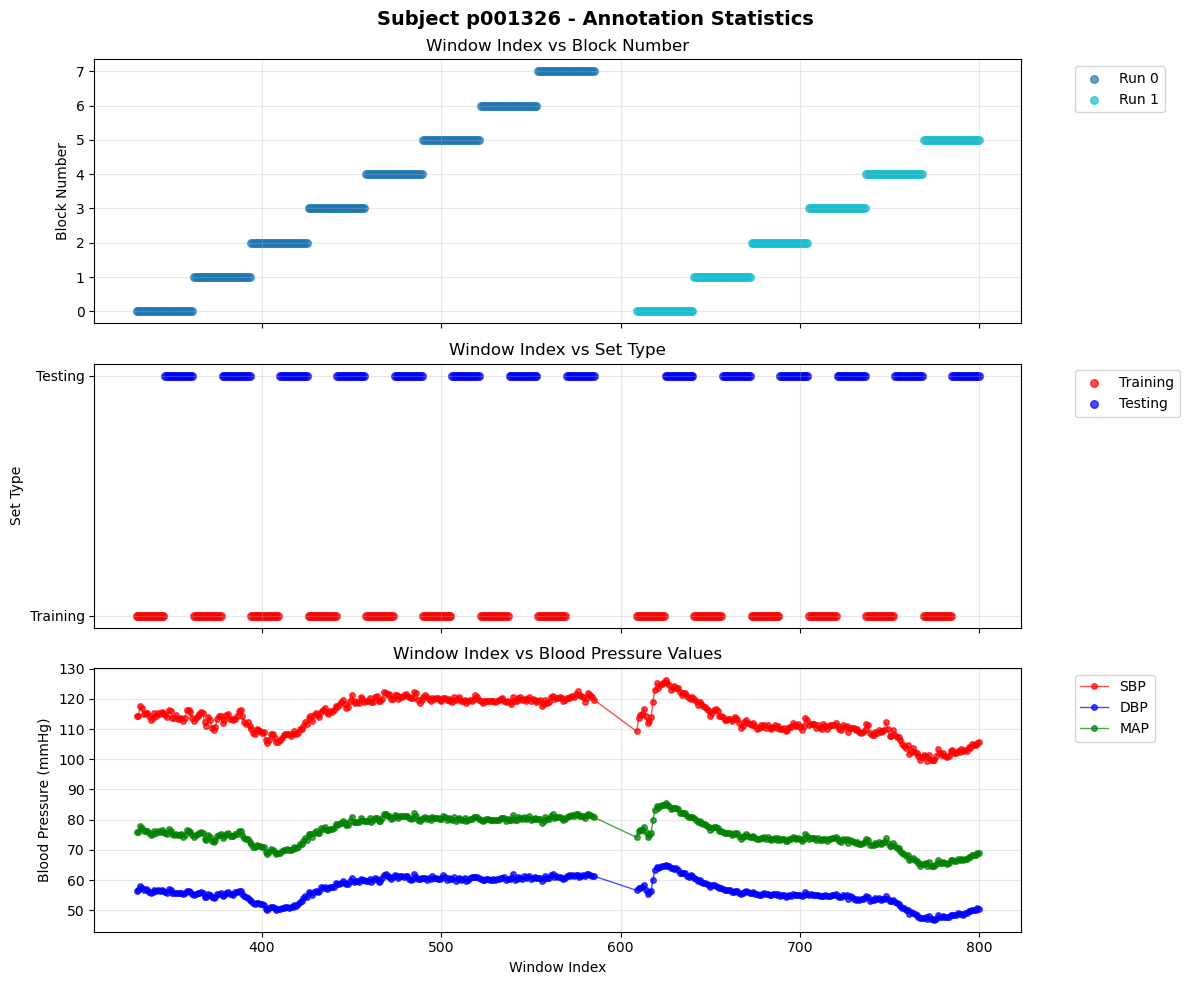

In [3]:
# Get a subject data: p001326, data contains all samples of a subject, both valid and invalid samples
data = np.load(config['samples_path'], allow_pickle=True)

# Get valid indices for that subject, their indices are recorded in a pickle file
with open(config['runs_path'], "rb") as f:
    runs = pickle.load(f)
print(f"Subject {subject_id} has {len(runs)} blocks of contiguous valid samples, each with {config['personalization_batch_size']} samples for training and {config['personalization_batch_size']} samples for validation")

# Visualization of the runs: a run is a seuquence of contiguous valid windows
plot_subject_annotation_runs_from_files(
    data=data,
    runs=runs,
    subject_id=subject_id
)

## Model Definition

In [4]:
def get_learner():
    # Initialize architecture: encoder + prediction head
    encoder = get_encoder_architecture(config)
    prediction_head = get_prediction_head_architecture(config)
    learner = MAMLLearner(encoder, prediction_head)

    # Load weights from checkpoint saved during pretraining
    ckpt = torch.load(config['pretrained_model_ckpt_path'], map_location=device)
    learner.load_state_dict(ckpt['learner_state_dict'])
    learner = learner.to(device).eval()
    return learner

In [5]:
learner = get_learner()

# Define dummy input to print summary
example_shape = (1, config['fs'] * config['input_seq_len_s'])  # Example input
summary(learner, input_size=example_shape)

/tmp/ipykernel_152578/70803541.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(config['pretrained_model_ckpt_path'], map_location=device)


Layer (type:depth-idx)                        Output Shape              Param #
MAMLLearner                                   [1, 3]                    --
├─ResGruNet: 1-1                              [1, 19, 256]              --
│    └─TemporalBlock: 2-1                     [1, 19, 256]              --
│    │    └─ModuleList: 3-1                   --                        437,002
│    └─GRU: 2-2                               [1, 19, 256]              394,752
│    └─GroupNorm: 2-3                         [1, 256, 19]              512
├─ResGruNetPredictionHead: 1-2                [1, 3]                    --
│    └─BPRegressor: 2-4                       [1, 3]                    --
│    │    └─Sequential: 3-2                   [1, 3]                    107,139
Total params: 939,405
Trainable params: 939,405
Non-trainable params: 0
Total mult-adds (M): 21.79
Input size (MB): 0.01
Forward/backward pass size (MB): 8.42
Params size (MB): 3.76
Estimated Total Size (MB): 12.18

## Deployment

In [21]:
def personalization_loop(learner, runs, data, config, device):
    enc, ph = learner.encoder, learner.prediction_head
    enc.eval(); ph.eval()

    mae_per_block, std_per_block = [], []
    train_macs_per_block, val_macs_per_block = [], []

    for block_idx, block in enumerate(runs):
        print(f"\n🟡 Starting block {block_idx+1}/{len(runs)}")

        # --- Adaptation phase ---
        enc.train(); ph.train()
        inner_opt = build_inner_optimizer(enc, ph, base_lr=config['personalization_lr'], config=config)
        B = config['personalization_batch_size']

        # --- Start counter for training MACs ---
        total_train_macs = 0
        train_forward_passes = 0
        
        for step in range(config['personalization_steps']):
            for i in range(0, len(block['train']), B):
                batch_ids = block['train'][i:i+B]

                # --- Build mini-batch ---
                signals_list, targets_list = [], []
                for sid in batch_ids:
                    idx = int(np.where(data['idxs'] == sid)[0])
                    sig = torch.tensor(np.array(data['ppgs'][idx]), dtype=torch.float32).unsqueeze(-1)
                    target = torch.stack([
                        torch.tensor(np.array(data['sbps'][idx])), 
                        torch.tensor(np.array(data['dbps'][idx])), 
                        torch.tensor(np.array(data['maps'][idx]))
                    ], dim=-1)
                    signals_list.append(sig)
                    targets_list.append(target)

                signals = torch.stack(signals_list).to(device)
                targets = torch.stack(targets_list).to(device)
                
                # --- Count MACs for forward pass ---
                # Create a wrapper model for MAC counting
                class ForwardModel(torch.nn.Module):
                    def __init__(self, encoder, pred_head):
                        super().__init__()
                        self.encoder = encoder
                        self.pred_head = pred_head
                    
                    def forward(self, x):
                        return self.pred_head(self.encoder(x))
                
                # Profile only once per batch to avoid overhead
                if train_forward_passes == 0:
                    forward_model = ForwardModel(enc, ph)
                    # Clone input to avoid modifying the original
                    sample_input = signals.clone()
                    macs, params = profile(forward_model, inputs=(sample_input,), verbose=False)
                    # For training, count both forward and backward (backward ≈ 2x forward)
                    macs_per_forward = macs
                    total_train_macs += macs_per_forward * 3  # 1 forward + 2 backward
                else:
                    # Reuse the previously calculated MACs
                    total_train_macs += macs_per_forward * 3
                
                train_forward_passes += 1
                
                outputs = ph(enc(signals))
                loss = F.smooth_l1_loss(outputs, targets) if config['criterion'] == 'SmoothL1Loss' else F.mse_loss(outputs, targets)

                inner_opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(ph.parameters()), config['grad_clip'])
                inner_opt.step()
        
        # --- Stop counter for training MACs ---
        avg_train_macs = total_train_macs / max(train_forward_passes, 1)
        train_macs_per_block.append(total_train_macs)
        print(f"🔧 Training MACs: {total_train_macs / 1e9:.2f} GMACs (avg per batch: {avg_train_macs / 1e9:.2f} GMACs)")
        
        # --- Validation phase ---
        
        # --- Start counter for validation MACs ---
        enc.eval(); ph.eval()
        signals_list, targets_list = [], []
        for sid in block['test']:
            idx = int(np.where(data['idxs'] == sid)[0])
            sig = torch.tensor(np.array(data['ppgs'][idx]), dtype=torch.float32).unsqueeze(-1)
            target = torch.stack([
                torch.tensor(np.array(data['sbps'][idx])), 
                torch.tensor(np.array(data['dbps'][idx])), 
                torch.tensor(np.array(data['maps'][idx]))
            ], dim=-1)
            signals_list.append(sig)
            targets_list.append(target)

        signals = torch.stack(signals_list).to(device)
        targets = torch.stack(targets_list).cpu().numpy()
        
        # --- Count MACs for validation forward pass ---
        with torch.no_grad():
            forward_model = ForwardModel(enc, ph)
            sample_input = signals.clone()
            val_macs, params = profile(forward_model, inputs=(sample_input,), verbose=False)
        
        preds = ph(enc(signals)).detach().cpu().numpy()
        
        # --- Stop counter for validation MACs ---
        val_macs_per_block.append(val_macs)
        print(f"🔍 Validation MACs: {val_macs / 1e6:.2f} MMACs")

        # --- Error calculation ---
        abs_errs = np.abs(preds - targets)
        per_sample_mae = np.mean(abs_errs, axis=1)
        error = float(np.mean(per_sample_mae))
        error_std = float(np.std(per_sample_mae))

        mae_per_block.append(error)
        std_per_block.append(error_std)

        print(f"✅ Block {block_idx+1}: MAE = {error:.3f} ± {error_std:.3f}")

    # --- Summary statistics ---
    print(f"\n📊 MAC Statistics:")
    print(f"  Total Training MACs: {sum(train_macs_per_block) / 1e9:.2f} GMACs")
    print(f"  Total Validation MACs: {sum(val_macs_per_block) / 1e9:.2f} GMACs")
    print(f"  Avg Training MACs per block: {np.mean(train_macs_per_block) / 1e9:.2f} ± {np.std(train_macs_per_block) / 1e9:.2f} GMACs")
    print(f"  Avg Validation MACs per block: {np.mean(val_macs_per_block) / 1e6:.2f} ± {np.std(val_macs_per_block) / 1e6:.2f} MMACs")

    return mae_per_block, std_per_block

In [22]:
# Always get a fresh learner when running this cell
learner = get_learner()
mae_per_block, std_per_block = personalization_loop(learner, runs, data, config, device)

/tmp/ipykernel_152578/70803541.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(config['pretrained_model_ckpt_path'], map_location=device)



🟡 Starting block 1/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 1: MAE = 1.383 ± 0.559

🟡 Starting block 2/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 2: MAE = 1.654 ± 1.084

🟡 Starting block 3/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 3: MAE = 1.012 ± 0.541

🟡 Starting block 4/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 4: MAE = 3.604 ± 0.874

🟡 Starting block 5/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 5: MAE = 0.605 ± 0.313

🟡 Starting block 6/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 6: MAE = 0.571 ± 0.363

🟡 Starting block 7/14
🔧 Training MACs: 21.96 GMACs (avg per batch: 2.75 GMACs)
🔍 Validation MACs: 915.14 MMACs
✅ Block 7: MAE = 0.575 ± 0.200

In [23]:
def plot_mae_with_std(mae_per_block, std_per_block, subject_id):
    """
    Plot MAE per block with standard deviation as error bars or shaded area.

    Parameters
    ----------
    mae_per_block : list or np.ndarray
        Mean absolute errors for each block.
    std_per_block : list or np.ndarray
        Standard deviation of absolute errors for each block.
    subject_id : str
        Subject identifier (for title).
    savepath : str, optional
        If provided, save the plot to this path.
    show : bool, default=True
        If True, display the plot instead of saving only.
    """

    mae_per_block = np.array(mae_per_block)
    std_per_block = np.array(std_per_block)
    blocks = np.arange(1, len(mae_per_block) + 1)

    plt.figure(figsize=(12, 7))
    plt.plot(blocks, mae_per_block, marker="o", color="tab:red", label="MAE")
    plt.fill_between(
        blocks,
        mae_per_block - std_per_block,
        mae_per_block + std_per_block,
        color="tab:red",
        alpha=0.2,
        label="± STD"
    )

    plt.xlabel("Block Index", fontsize=12)
    plt.ylabel("Mean Absolute Error (mmHg)", fontsize=12)
    plt.title(f"Subject {subject_id} – Online Adaptation Error (MAE ± STD)", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

    plt.show()

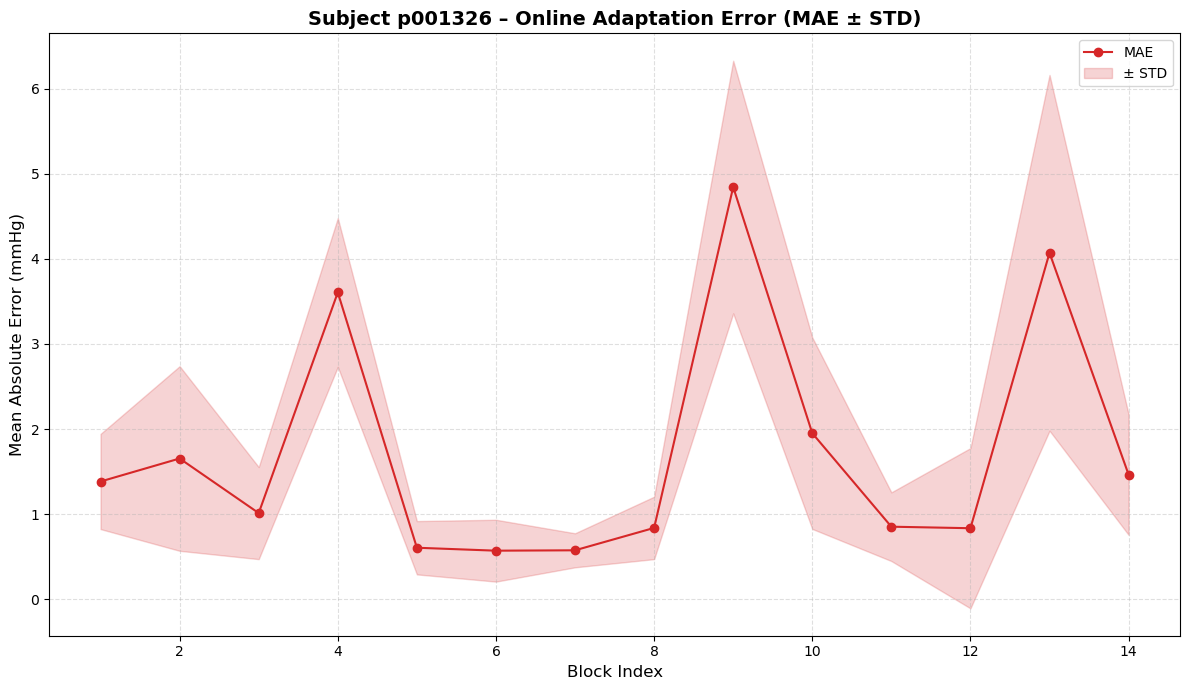

In [24]:
# Visualize metric during online learning
plot_mae_with_std(mae_per_block, std_per_block, subject_id)